# PODCNF Library

This notebook will explain you how to use properly the library from the loading of the data, following the POD, the data preprocessing, the training and finally to evaluate the goodness of the model.

> Imports and device setting

In [1]:
import torch
import numpy as np

from podcnf import PODcnf
from podcnf.DataManage import DataPreprocessing
from podcnf.NFmodel import NormalizingFlow

from dlroms import euclidean
from dlroms import num2p

SEED = 42

/home/andreaviolante1501/podcnf/.venv/lib/python3.12/site-packages/dlroms/fespaces.py:51: UserWarning: Either dolfin or fenics are not available. Some functions might not be available or work as expected.
  warnings.warn("Either dolfin or fenics are not available. Some functions might not be available or work as expected.")


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.12.0+cpu
Device: cpu


## Forward

### Loading Data

In this section you should upload you data. These are composed by the soultions $u$, that might be your reference data to infer on, and the conditioning parameters in the vector $\mu$.
These two ingredients must be tensors on the same device.

In [ ]:
# # Linear Elasticity Problem
# data = torch.load("../data/data_linear_density_2pi.pt", weights_only=True)
# u = data['u_data'].to(device)
# mass = data['mass']
# delta = data['delta']
# mu = torch.cat([mass, delta], dim = 1).to(device)
# dim_mu = mu.shape[1]

In [4]:
# Advection-Diffusion Problem
data = torch.load("../data/stokes_data_6400.pt", weights_only=True)
u = data['u']
mu = data['mu']
dim_mu = mu.shape[1]

### POD

Once data are loaded the POD must be computed to project the data into a low dimensional space obtaining the latent coefficients that are then used to train the model.

Note that here ```n_train``` and ```n_val``` are meant to be index that separates the training set from the validation set, so then the rest of the data could be used to test the model.

In [5]:
n_samples = u.shape[0]
n_train = int(n_samples * 0.75)
n_val = int(n_train + n_samples * 0.2)

<Figure size 700x500 with 0 Axes>

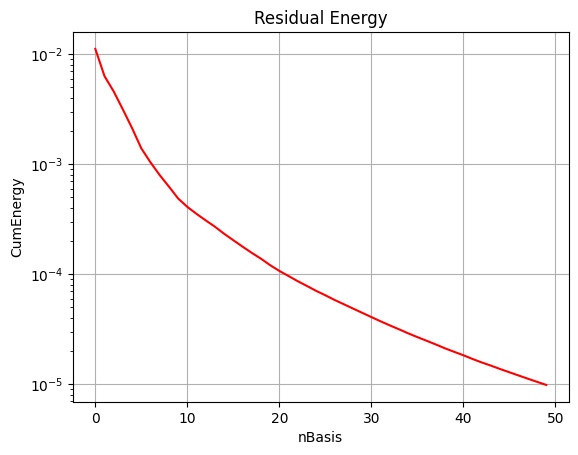

In [6]:
V, svalues = PODcnf.svd(u[:n_train, :].T)
PODcnf.svdplot(svalues, nmax = 100, logscale = True)

In [8]:
n = PODcnf.nmin(svalues, threshold = 0.9999)
Vpod = V[:, :n]
print(f"Choosen number of basis: {n}")
errors = PODcnf.projection_errors(u[n_train:n_val, :], Vpod, relative = True, norm = euclidean)
print("Basis projection error (EUCLIDEAN): %s." % num2p(errors.mean()))

# l2 = L2(Vh)
# l2.to(dv)
# errors = PODcnf.projection_errors(u[n_train:n_val, :], Vpod, relative = True, norm = l2)
# print("Basis projection error (L2-integral): %s." % num2p(errors.mean()))

Choosen number of basis: 20
Basis projection error (EUCLIDEAN): 1.05%.


Saving the test dataset would be helpfull for the validation of the model

In [9]:
test_data_dict = {
    'u_test': u[n_val:],
    'mu_test': mu[n_val:]
}

torch.save(test_data_dict, "../results/elastic/test_data.pt")

### Data Preprocessing

In this section we project the data into the low-dimensional space applying the POD matrix ```Vpod```. The obtained latent coephicients should be then normalized before the training.

In [10]:
c = u @ Vpod
dim_c = c.shape[1]

In [11]:
c.shape

torch.Size([6400, 20])

In [12]:
train_data, val_data, test_data, mu_scaler, c_scaler = DataPreprocessing(
    mu, c, n_train, n_val, BATCH_SIZE = 64
)

### Tuning and Training

For the Tuning and Training section, one could may skip the tuning phase and just set a desired set of hyperparameters.

In [ ]:
lr = [1e-3]
num_flows = [16, 24]
hidden_size = [256]
hidden_depth = [1, 2]
wd = [1e-5]

tuning_epochs = 50
print_frequency = 10
patience = 20

In [ ]:
best_hyperparams = NormalizingFlow.tune_flow(
    train_data, val_data,
    lr, num_flows, hidden_size, hidden_depth, wd,
    tuning_epochs, print_frequency, patience,
    dim_mu, dim_c
)

In [ ]:
num_flows = best_hyperparams['num_flows']
hidden_size=best_hyperparams['hidden_size'] 
hidden_depth=best_hyperparams['hidden_depth']

In [ ]:
flow = NormalizingFlow(
    dim_mu, dim_c, 
    num_flows=best_hyperparams['num_flows'], 
    hidden_size=best_hyperparams['hidden_size'], 
    hidden_depth=best_hyperparams['hidden_depth'], 
    device=device
).to(device)

In [ ]:
model_save_path = '../results/stokes/TrialModel.pt'

In [ ]:
train_losses, val_losses = flow.train_flow(
    epochs=100, 
    print_frequency=10, 
    train_data = train_data, 
    val_data = val_data, 
    lr = best_hyperparams['learning_rate'], 
    weight_decay = best_hyperparams['weight_decay'], 
    patience = 20, 
    model_save_path = model_save_path, 
    show_plot=True
)

### Save the Model

In [ ]:
# rom = PODcnf(Vpod, flow, mu_scaler, c_scaler)
# rom.save("../results/stokes/stokesPODcnf.pt")

### Load the Model

In [15]:
test_data = torch.load("../results/elastic/test_data.pt")
u_test = test_data['u_test']
mu_test = test_data['mu_test']
n_test = u_test.shape[0]

In [ ]:
# loaded_rom = PODcnf.load("../results/stokes/stokesPODcnf.pt")
loaded_rom = PODcnf.load("../results/elastic/elasticPODcnf.pt")

### Model Evaluation

In [17]:
test_index = np.random.randint(0, n_test)
mu_sele = mu_test[test_index - 1, :]

In [34]:
loaded_rom.sample(mu_sele).shape

torch.Size([100, 1922])

Evaluation of the Negative Log-Likelihood (NLL)

In [35]:
loglikelihoods = loaded_rom.coef_Log_Likelihood(mu_test, u_test)
-loglikelihoods.mean()

tensor(-101.9472)